## Yasir Alghamdi 2230004157 | Image processing | Lab 2

In [1]:
#Step1: Import the libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step2: Define Functions
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

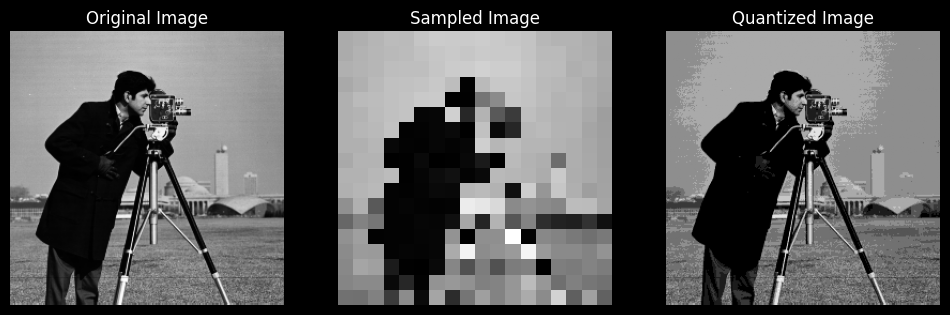

In [4]:
image_path = r'images/cameraman.tif'

sampling_factor = 14
quantization_levels = 9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise ValueError(f"Error: Unable to load image at {image_path}")

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)




# Arithmetic Operations

from PIL import Image
img1=Image.open(r'images\at3_1m4_01.tif')
img2=Image.open (r'images/cameraman.tif')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr
resultImage=Image.fromarray(addition)
resultImage.show()

#Sets and Logical Operations

img3 = Image.open('images/cameraman.tif')
img3.show()
img4 = Image.open('images/at3_1m4_01.tif')
img4.show()

resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)

im3arr=np.asarray(img3)
im4arr=np.asarray(img4)

union=im4arr|im3arr
resultImage2=Image.fromarray(union)
resultImage2.show()

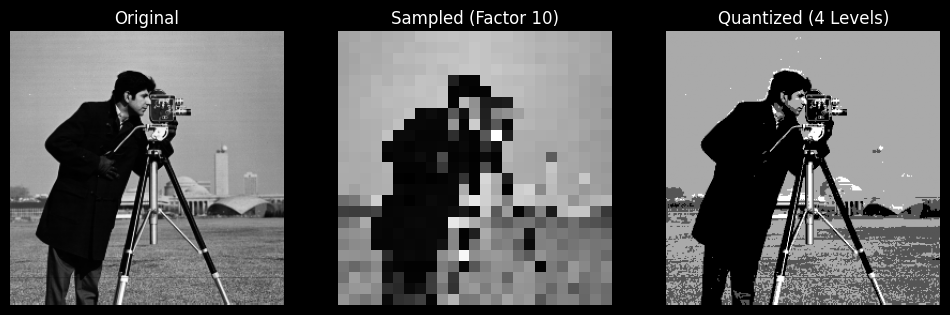

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Parameters to observe effects
# Try Factor 20 and Levels 2 for a dramatic "Lo-Fi" effect
sampling_factor = 10
quantization_levels = 4

image_path = 'images/cameraman.tif'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is not None:
    # 1. Sampling
    h, w = original_image.shape[:2]
    sampled = cv2.resize(original_image, (w // sampling_factor, h // sampling_factor), interpolation=cv2.INTER_NEAREST)

    # 2. Quantization
    quantized = np.floor(original_image / (256 // quantization_levels)) * (256 // quantization_levels)
    quantized = quantized.astype(np.uint8)

    # Plotting
    plt.figure(figsize=(12, 4))
    titles = ['Original', f'Sampled (Factor {sampling_factor})', f'Quantized ({quantization_levels} Levels)']
    imgs = [original_image, sampled, quantized]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

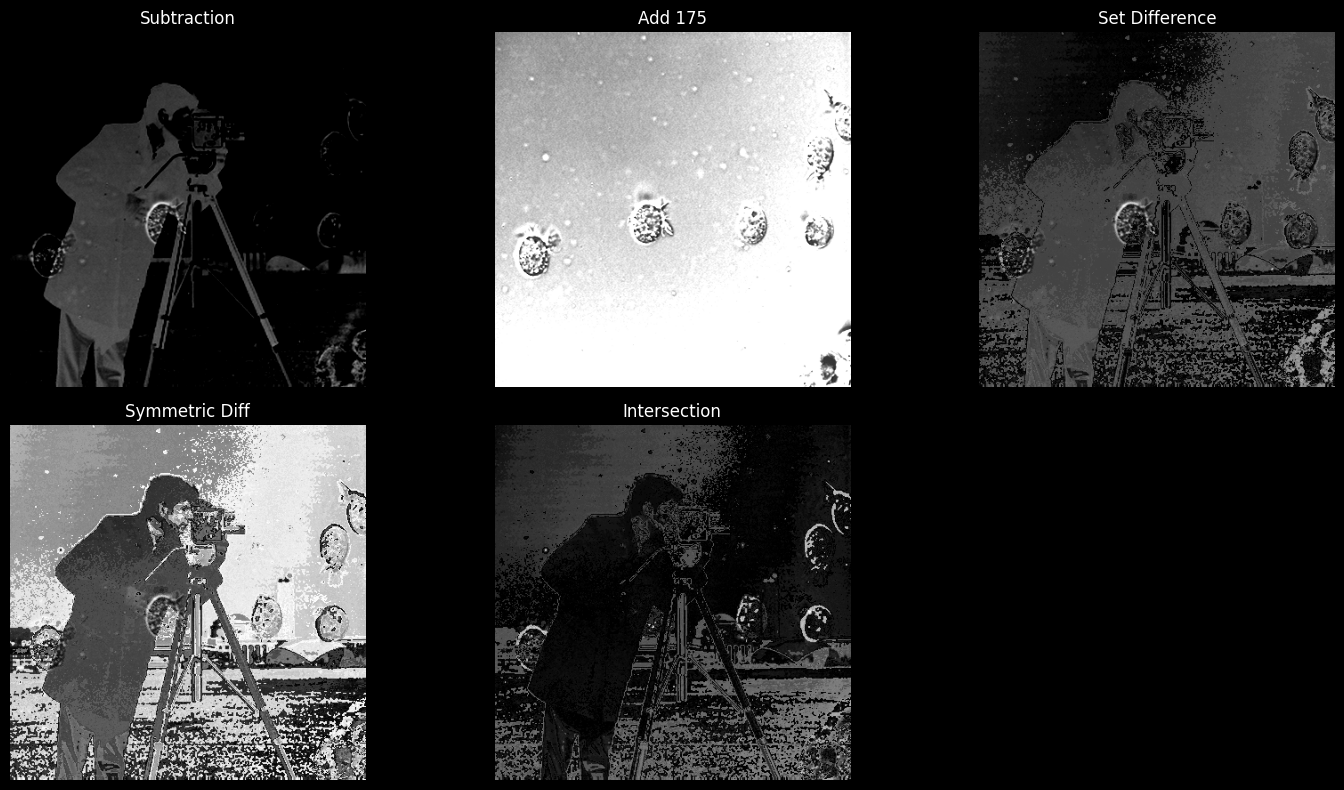

In [6]:
# Load and Resize images
img1 = Image.open('images/at3_1m4_01.tif').convert('L')
img2 = Image.open('images/cameraman.tif').convert('L')

resize_dim = (400, 400)
img1 = img1.resize(resize_dim, Image.Resampling.LANCZOS)
img2 = img2.resize(resize_dim, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1, dtype=np.int16) # Using int16 to prevent overflow/underflow during math
im2arr = np.asarray(img2, dtype=np.int16)

# 1. Subtract two images (clipping values to 0-255 range)
subtraction = np.clip(im1arr - im2arr, 0, 255).astype(np.uint8)

# 2. Add constant value of 175
addition_const = np.clip(im1arr + 175, 0, 255).astype(np.uint8)

# Convert back to uint8 for logical operations
im1_u8 = np.asarray(img1)
im2_u8 = np.asarray(img2)

# 3. Set Difference (A - B is often represented as A AND (NOT B))
# For grayscale, this can also be viewed as subtracting and keeping positive results
set_difference = cv2.bitwise_and(im1_u8, cv2.bitwise_not(im2_u8))

# 4. Symmetric Difference (XOR operation)
sym_difference = cv2.bitwise_xor(im1_u8, im2_u8)

# 5. Intersection (AND operation)
intersection = cv2.bitwise_and(im1_u8, im2_u8)

# --- Displaying Results ---
results = [subtraction, addition_const, set_difference, sym_difference, intersection]
labels = ['Subtraction', 'Add 175', 'Set Difference', 'Symmetric Diff', 'Intersection']

plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(results[i], cmap='gray')
    plt.title(labels[i])
    plt.axis('off')
plt.tight_layout()
plt.show()